In [2]:
# 必要なライブラリのimport
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Tensorflow
import tensorflow as tf

# データの分割
from sklearn.model_selection import train_test_split

# DataFrameで全ての列を表示する設定
pd.options.display.max_columns = None

# MSE
from sklearn.metrics import mean_squared_error

In [3]:
dataset = pd.read_csv("./train (5).csv")

In [4]:
dataset.head()

,id,loan_amnt,term,interest_rate,grade,employment_length,purpose,credit_score,application_type,loan_status
0,88194295,1800.0,3 years,14.49,C4,NaN,debt_consolidation,665.0,Individual,FullyPaid
1,5146039,1200.0,5 years,16.29,C4,2 years,debt_consolidation,700.0,Individual,ChargedOff
2,3095896,2000.0,5 years,21.98,E4,10 years,home_improvement,670.0,Individual,FullyPaid
3,88625044,1000.0,3 years,8.59,A5,4 years,debt_consolidation,710.0,Individual,FullyPaid
4,1178189,1500.0,3 years,13.99,C1,4 years,debt_consolidation,680.0,Individual,FullyPaid


In [5]:
# 欠損値NaNを0に置換する
dataset['employment_length'] = dataset['employment_length'].fillna('0 years')

In [6]:
# 欠損値を含む行を削除
# dataset = dataset.dropna()

In [7]:
def term_to_int(v):
    ret = v.split()[0]
    ret = int(ret)
    return ret
dataset['term'] = dataset['term'].apply(term_to_int)

In [8]:
def employment_length_to_int(v):
    ret = v.split()[0]
    ret = int(ret)
    return ret
dataset['employment_length'] = dataset['employment_length'].apply(employment_length_to_int)

In [9]:
dataset['loan_status'] = dataset['loan_status'].replace({
    'FullyPaid': 0,
    'ChargedOff': 1
})

C:\Users\user\AppData\Local\Temp\ipykernel_1524\1600627935.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset['loan_status'] = dataset['loan_status'].replace({


In [10]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242156 entries, 0 to 242155
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 242156 non-null  int64  
 1   loan_amnt          242156 non-null  float64
 2   term               242156 non-null  int64  
 3   interest_rate      242156 non-null  float64
 4   grade              242156 non-null  object 
 5   employment_length  242156 non-null  int64  
 6   purpose            242156 non-null  object 
 7   credit_score       242156 non-null  float64
 8   application_type   242156 non-null  object 
 9   loan_status        242156 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 18.5+ MB


In [11]:
#欠損値の確認
dataset.isnull().sum()

id                   0
loan_amnt            0
term                 0
interest_rate        0
grade                0
employment_length    0
purpose              0
credit_score         0
application_type     0
loan_status          0
dtype: int64

In [12]:
dataset.head()

,id,loan_amnt,term,interest_rate,grade,employment_length,purpose,credit_score,application_type,loan_status
0,88194295,1800.0,3,14.49,C4,0,debt_consolidation,665.0,Individual,0
1,5146039,1200.0,5,16.29,C4,2,debt_consolidation,700.0,Individual,1
2,3095896,2000.0,5,21.98,E4,10,home_improvement,670.0,Individual,0
3,88625044,1000.0,3,8.59,A5,4,debt_consolidation,710.0,Individual,0
4,1178189,1500.0,3,13.99,C1,4,debt_consolidation,680.0,Individual,0


In [13]:
# データの形状を確認
dataset.shape

(242156, 10)

In [14]:
# 全体的な情報を表示
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242156 entries, 0 to 242155
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 242156 non-null  int64  
 1   loan_amnt          242156 non-null  float64
 2   term               242156 non-null  int64  
 3   interest_rate      242156 non-null  float64
 4   grade              242156 non-null  object 
 5   employment_length  242156 non-null  int64  
 6   purpose            242156 non-null  object 
 7   credit_score       242156 non-null  float64
 8   application_type   242156 non-null  object 
 9   loan_status        242156 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 18.5+ MB


In [15]:
# 行番号を確認
dataset.index.values

array([     0,      1,      2, ..., 242153, 242154, 242155])

In [16]:
# 列ラベルを確認
dataset.columns.values

array(['id', 'loan_amnt', 'term', 'interest_rate', 'grade',
       'employment_length', 'purpose', 'credit_score', 'application_type',
       'loan_status'], dtype=object)

In [17]:
# 行番号は数値型
print(type(dataset.index.values[0]))
# 列ラベルは文字型
print(type(dataset.columns.values[0]))

<class 'numpy.int64'>
<class 'str'>


In [18]:
# 列の型を確認
dataset.dtypes

id                     int64
loan_amnt            float64
term                   int64
interest_rate        float64
grade                 object
employment_length      int64
purpose               object
credit_score         float64
application_type      object
loan_status            int64
dtype: object

In [19]:
#employment_lengthとloan_statusの相関をグラフで見る

In [20]:
# 要約統計量を表示
dataset.describe(include='all')

,id,loan_amnt,term,interest_rate,grade,employment_length,purpose,credit_score,application_type,loan_status
count,2.421560e+05,242156.000000,242156.000000,242156.000000,242156,242156.000000,242156,242156.000000,242156,242156.000000
unique,NaN,NaN,NaN,NaN,35,NaN,13,NaN,2,NaN
top,NaN,NaN,NaN,NaN,B3,NaN,debt_consolidation,NaN,Individual,NaN
freq,NaN,NaN,NaN,NaN,16937,NaN,141059,NaN,236086,NaN
mean,5.642844e+07,1417.203456,3.441509,13.988211,NaN,5.639848,NaN,697.442331,NaN,0.199628
std,4.790252e+07,872.780311,0.829512,4.847934,NaN,3.803180,NaN,31.922166,NaN,0.399721
min,5.571600e+04,100.000000,3.000000,5.320000,NaN,0.000000,NaN,660.000000,NaN,0.000000
25%,3.357649e+06,750.000000,3.000000,10.640000,NaN,2.000000,NaN,675.000000,NaN,0.000000
50%,8.558081e+07,1200.000000,3.000000,13.490000,NaN,6.000000,NaN,690.000000,NaN,0.000000
75%,9.245125e+07,2000.000000,3.000000,16.990000,NaN,10.000000,NaN,715.000000,NaN,0.000000


In [21]:
#カテゴリー変数
dataset2 = pd.get_dummies(data=dataset, columns=['grade' ,'purpose' ,'application_type'], dtype=int)
dataset2.head()

,id,loan_amnt,term,interest_rate,employment_length,credit_score,loan_status,grade_A1,grade_A2,grade_A3,grade_A4,grade_A5,grade_B1,grade_B2,grade_B3,grade_B4,grade_B5,grade_C1,grade_C2,grade_C3,grade_C4,grade_C5,grade_D1,grade_D2,grade_D3,grade_D4,grade_D5,grade_E1,grade_E2,grade_E3,grade_E4,grade_E5,grade_F1,grade_F2,grade_F3,grade_F4,grade_F5,grade_G1,grade_G2,grade_G3,grade_G4,grade_G5,purpose_car,purpose_credit_card,purpose_debt_consolidation,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,application_type_Individual,application_type_Joint App
0,88194295,1800.0,3,14.49,0,665.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
1,5146039,1200.0,5,16.29,2,700.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
2,3095896,2000.0,5,21.98,10,670.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
3,88625044,1000.0,3,8.59,4,710.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
4,1178189,1500.0,3,13.99,4,680.0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0


<Axes: xlabel='loan_status', ylabel='employment_length'>

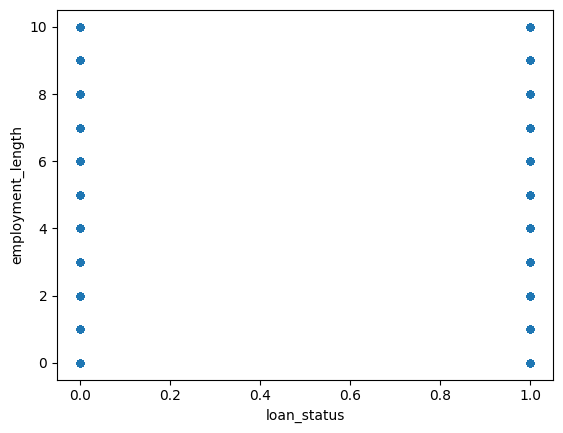

In [22]:
# 散布図を表示
dataset.plot(kind='scatter', x='loan_status', y='employment_length')

In [23]:
# 列の型を確認
dataset2.dtypes

id                               int64
loan_amnt                      float64
term                             int64
interest_rate                  float64
employment_length                int64
credit_score                   float64
loan_status                      int64
grade_A1                         int64
grade_A2                         int64
grade_A3                         int64
grade_A4                         int64
grade_A5                         int64
grade_B1                         int64
grade_B2                         int64
grade_B3                         int64
grade_B4                         int64
grade_B5                         int64
grade_C1                         int64
grade_C2                         int64
grade_C3                         int64
grade_C4                         int64
grade_C5                         int64
grade_D1                         int64
grade_D2                         int64
grade_D3                         int64
grade_D4                 

In [24]:
#正規化は一様分布のMin-Max Normalizationをつかおう
# Min-Max Normalization
from sklearn.preprocessing import MinMaxScaler
ms = MinMaxScaler()
dataset2_norm = ms.fit_transform(dataset2)
dataset2_norm

array([[0.69749968, 0.43589744, 0.        , ..., 0.        , 1.        ,
        0.        ],
       [0.04028314, 0.28205128, 1.        , ..., 0.        , 1.        ,
        0.        ],
       [0.02405898, 0.48717949, 1.        , ..., 0.        , 1.        ,
        0.        ],
       ...,
       [0.97772529, 0.17435897, 0.        , ..., 0.        , 1.        ,
        0.        ],
       [0.01781172, 0.09551282, 0.        , ..., 0.        , 1.        ,
        0.        ],
       [0.72197203, 0.29487179, 0.        , ..., 0.        , 0.        ,
        1.        ]])

In [25]:
# データの形状を確認
dataset2.shape

(242156, 57)

In [26]:
dataset2.head()

,id,loan_amnt,term,interest_rate,employment_length,credit_score,loan_status,grade_A1,grade_A2,grade_A3,grade_A4,grade_A5,grade_B1,grade_B2,grade_B3,grade_B4,grade_B5,grade_C1,grade_C2,grade_C3,grade_C4,grade_C5,grade_D1,grade_D2,grade_D3,grade_D4,grade_D5,grade_E1,grade_E2,grade_E3,grade_E4,grade_E5,grade_F1,grade_F2,grade_F3,grade_F4,grade_F5,grade_G1,grade_G2,grade_G3,grade_G4,grade_G5,purpose_car,purpose_credit_card,purpose_debt_consolidation,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,application_type_Individual,application_type_Joint App
0,88194295,1800.0,3,14.49,0,665.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
1,5146039,1200.0,5,16.29,2,700.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
2,3095896,2000.0,5,21.98,10,670.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
3,88625044,1000.0,3,8.59,4,710.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
4,1178189,1500.0,3,13.99,4,680.0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0


In [27]:
# 目的変数（Y)：loan_status、説明変数（X)：それ以外の列
Y = np.array(dataset2['loan_status'])
X = np.array(dataset2.drop(columns=['loan_status']))

In [28]:
# 形状を確認
print("Y=", Y.shape, ", X=", X.shape)

Y= (242156,) , X= (242156, 56)


In [29]:
# データの分割
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0)
X_train, X_valid, Y_train, Y_valid = train_test_split(X_train, Y_train, test_size=0.3, random_state=0)


In [30]:
# 形状を確認
print("Y_train=", Y_train.shape, ", X_train=", X_train.shape)
print("Y_valid=", Y_valid.shape, ", X_valid=", X_valid.shape)
print("Y_test=", Y_test.shape, ", X_test=", X_test.shape)

Y_train= (118656,) , X_train= (118656, 56)
Y_valid= (50853,) , X_valid= (50853, 56)
Y_test= (72647,) , X_test= (72647, 56)


In [37]:
# モデルの初期化
model = tf.keras.Sequential([
    # 入力層
    tf.keras.Input(shape=(56,)),
    tf.keras.layers.Dense(64, activation='relu'),
    # 隠れ層
    tf.keras.layers.Dense(64, activation='relu'),
    # 出力層
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# モデルの構築
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [38]:
# モデルの構造を表示
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         3,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,873 (30.75 KB)

 Trainable params: 7,873 (30.75 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
print(X_train.shape)

(118656, 56)


In [40]:
np.unique(Y_train)

array([0, 1])

In [41]:
# 学習の実施
log = model.fit(X_train, Y_train, epochs=1000, batch_size=32, verbose=True,
                callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                            min_delta=0, patience=30,
                                                            verbose=1)],
                validation_data=(X_valid, Y_valid))

Epoch 1/1000
3708/3708 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.6647 - loss: 55160.7539 - val_accuracy: 0.2982 - val_loss: 8038.6841
Epoch 2/1000
3708/3708 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6695 - loss: 20433.7793 - val_accuracy: 0.8000 - val_loss: 18062.1113
Epoch 3/1000
3708/3708 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6777 - loss: 9015.0381 - val_accuracy: 0.2001 - val_loss: 6681.0981
Epoch 4/1000
3708/3708 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6766 - loss: 1922.6614 - val_accuracy: 0.8000 - val_loss: 14.1017
Epoch 5/1000
3708/3708 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7614 - loss: 80.9464 - val_accuracy: 0.8000 - val_loss: 0.5004
Epoch 6/1000
3708/3708 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8009 - loss: 0.4994 - val_accuracy: 0.8000 - val_loss: 0.5004
Epoch 7/1000
3708/3708 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8010 - loss: 0.4991 - val_accuracy: 0.8000 - val_loss: 0.5004
Epoch 8/1000
3708/3708 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms

Text(0, 0.5, 'crossentropy')

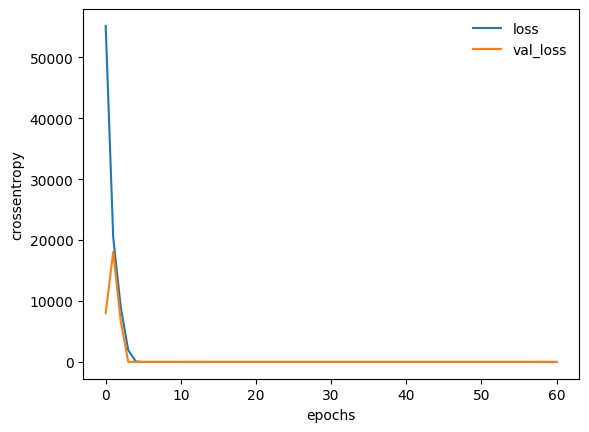

In [42]:
# グラフ表示
plt.plot(log.history['loss'], label='loss')
plt.plot(log.history['val_loss'], label='val_loss')
plt.legend(frameon=False) # 凡例の表示
plt.xlabel("epochs")
plt.ylabel("crossentropy")

In [43]:
# predictで予測を行なう
Y_pred = model.predict(X_test)

2271/2271 ━━━━━━━━━━━━━━━━━━━━ 2s 908us/step


In [46]:
# Y_predを表示
Y_pred


array([[0.19417629],
       [0.19417629],
       [0.19417629],
       ...,
       [0.19417629],
       [0.19417629],
       [0.19417629]], dtype=float32)

In [47]:
# 二値分類は予測結果の確率が0.5以下なら0,
# それより大きければ1となる計算で求める
Y_pred_cls = (Y_pred > 0.5).astype("int32")
Y_pred_cls

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], dtype=int32)

In [54]:
# 形状を正解（目的変数）に合わせる
Y_pred_ = Y_pred_cls.reshape(-1)

In [62]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, Y_pred_))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     58090
           1       0.00      0.00      0.00     14557

    accuracy                           0.80     72647
   macro avg       0.40      0.50      0.44     72647
weighted avg       0.64      0.80      0.71     72647



c:\Users\user\Downloads\aidev\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user\Downloads\aidev\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user\Downloads\aidev\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
